In [1]:
import numpy as np

def gaussian_kernel(distance, bandwidth):
    return np.exp(-0.5 * (distance / bandwidth) ** 2)

def mean_shift(points, bandwidth=1.0, max_iter=100, tol=1e-3):
    shifted_points = np.copy(points)

    for i in range(len(points)):
        point = shifted_points[i]

        for _ in range(max_iter):
            distances = np.linalg.norm(point - points, axis=1)
            weights = gaussian_kernel(distances, bandwidth)

            new_point = np.sum(points * weights[:, None], axis=0) / np.sum(weights)

            if np.linalg.norm(new_point - point) < tol:
                break

            point = new_point

        shifted_points[i] = point

    return shifted_points


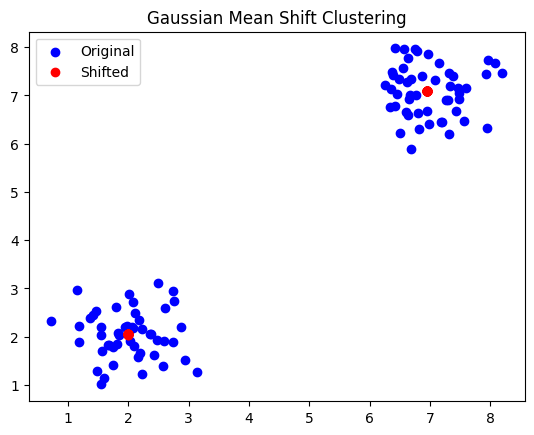

In [2]:
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(0)
data1 = np.random.normal([2, 2], 0.5, (50, 2))
data2 = np.random.normal([7, 7], 0.5, (50, 2))
data = np.vstack((data1, data2))

# Apply mean shift
shifted = mean_shift(data, bandwidth=1.0)

# Plot results
plt.scatter(data[:, 0], data[:, 1], c='blue', label='Original')
plt.scatter(shifted[:, 0], shifted[:, 1], c='red', label='Shifted')
plt.legend()
plt.title("Gaussian Mean Shift Clustering")
plt.show()


In [3]:
from sklearn.cluster import MeanShift

ms = MeanShift(bandwidth=1.0)
ms.fit(data)

labels = ms.labels_
centers = ms.cluster_centers_

print("Cluster centers:\n", centers)


Cluster centers:
 [[6.89140271 7.07089939]
 [1.974408   2.01598093]]


In [4]:
# reshape image to (N, 3) for RGB
pixels = image.reshape(-1, 3)
ms = MeanShift(bandwidth=20)
ms.fit(pixels)
segmented = ms.labels_.reshape(image.shape[:2])


NameError: name 'image' is not defined

Estimated Bandwidth: 267.9715822417375


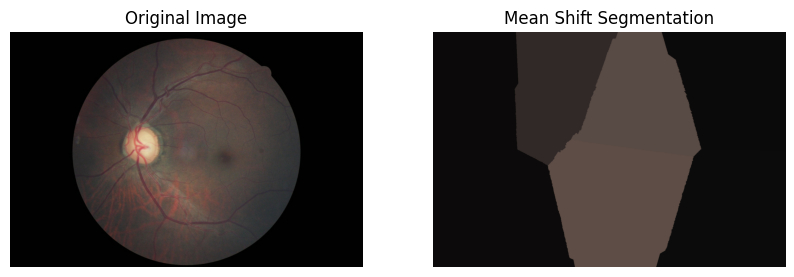

In [5]:
import cv2
import numpy as np
from sklearn.cluster import MeanShift, estimate_bandwidth
import matplotlib.pyplot as plt

# ---------- Load image ----------
image = cv2.imread("retina.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w, c = image.shape

# ---------- Create feature space ----------
# RGB features
rgb = image.reshape((-1, 3))

# Spatial features (x, y)
x, y = np.meshgrid(np.arange(w), np.arange(h))
spatial = np.column_stack((x.flatten(), y.flatten()))

# Combine RGB + spatial
features = np.hstack((rgb, spatial))

# ---------- Estimate bandwidth ----------
bandwidth = estimate_bandwidth(features, quantile=0.1, n_samples=500)
print("Estimated Bandwidth:", bandwidth)

# ---------- Apply Gaussian Mean Shift ----------
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(features)

labels = ms.labels_
cluster_centers = ms.cluster_centers_

# ---------- Reconstruct segmented image ----------
segmented = cluster_centers[labels][:, :3]
segmented = segmented.reshape((h, w, 3)).astype(np.uint8)

# ---------- Display ----------
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmented)
plt.title("Mean Shift Segmentation")
plt.axis("off")

plt.show()


In [6]:
pip install numpy opencv-python scikit-learn matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Estimated Bandwidth: 267.9715822417375


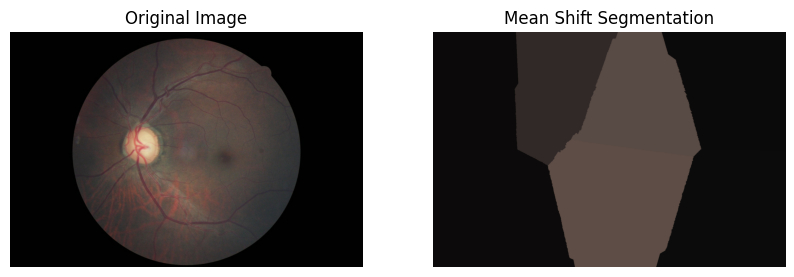

In [7]:
import cv2
import numpy as np
from sklearn.cluster import MeanShift, estimate_bandwidth
import matplotlib.pyplot as plt

# ---------- Load image ----------
image = cv2.imread("retina.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w, c = image.shape

# ---------- Create feature space ----------
# RGB features
rgb = image.reshape((-1, 3))

# Spatial features (x, y)
x, y = np.meshgrid(np.arange(w), np.arange(h))
spatial = np.column_stack((x.flatten(), y.flatten()))

# Combine RGB + spatial
features = np.hstack((rgb, spatial))

# ---------- Estimate bandwidth ----------
bandwidth = estimate_bandwidth(features, quantile=0.1, n_samples=500)
print("Estimated Bandwidth:", bandwidth)

# ---------- Apply Gaussian Mean Shift ----------
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(features)

labels = ms.labels_
cluster_centers = ms.cluster_centers_

# ---------- Reconstruct segmented image ----------
segmented = cluster_centers[labels][:, :3]
segmented = segmented.reshape((h, w, 3)).astype(np.uint8)

# ---------- Display ----------
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmented)
plt.title("Mean Shift Segmentation")
plt.axis("off")

plt.show()
